## Тема: Базовая предобработка изображений

---

### 1. Зачем нужна предобработка изображений?

Предобработка — это первый этап в задачах компьютерного зрения и распознавания изображений.
Она необходима для:

* улучшения качества изображения;
* устранения шумов, искажений, лишней информации;
* приведения всех данных к единому виду (размер, цвет, яркость);
* подготовки изображений к дальнейшему анализу: выделению признаков, классификации, сегментации.

Пример:

* фотография, сделанная на разных устройствах, может отличаться по яркости, контрасту и цветовой гамме → без предобработки алгоритмы будут работать хуже.

---

### 2. Цветовые модели изображения

#### 2.1. RGB (Red, Green, Blue)

* Самая распространённая модель.
* Каждое изображение представляется как комбинация трёх каналов: **красного, зелёного и синего**.
* Один пиксель = три числа (например, `[125, 200, 80]`).
* Используется для отображения изображений на мониторах, телевизорах, смартфонах.

#### 2.2. Grayscale (оттенки серого)

* Изображение хранится в одном канале.
* Каждый пиксель = число от 0 (чёрный) до 255 (белый).
* Используется в задачах, где цвет не имеет значения (распознавание рукописных цифр, анализ структуры изображения).

#### 2.3. HSV (Hue, Saturation, Value)

* Более удобная модель для анализа цвета.
* **Hue (оттенок)** – положение на цветовом круге (0–360°).
  *в OpenCV Hue хранится в диапазоне **0–179** (градусы делятся пополам, чтобы уместиться в uint8) — это частая путаница при выборе порогов.*
* **Saturation (насыщенность)** – насколько цвет яркий или блеклый.
* **Value (яркость)** – светлота цвета.
* Пример: легко выделить только «красные» или только «зелёные» объекты.

---

### 3. Масштабирование изображений (Resizing)

Необходимость:

* приведение всех изображений к одному размеру (например, для подачи в нейронную сеть).
* уменьшение размера для ускорения обработки.

Методы интерполяции:

* **Nearest Neighbor (ближайший сосед)** – простой, быстрый, но низкое качество.
* **Bilinear (билинейная)** – учитывает 4 ближайших пикселя, более гладкий результат.
* **Bicubic (бикубическая)** – учитывает 16 пикселей, ещё более качественное масштабирование.

---

### 4. Геометрические преобразования изображений

#### 4.1. Поворот

* Изображение поворачивается на заданный угол вокруг центра.
* Используется, например, для аугментации данных (создания новых примеров).

#### 4.2. Отражение (flip)

* По горизонтали (зеркальное отражение).
* По вертикали (переворот вверх ногами).
* Применяется в распознавании лиц, жестов, объектов для увеличения обучающей выборки.

#### 4.3. Обрезка (crop)

* Вырезается определённая часть изображения.
* Применяется для выделения области интереса (например, лица на фотографии).

---

### 5. Изменение яркости и контраста

#### 5.1. Яркость

* Смещение всех значений пикселей на одну и ту же величину.
* Чем выше яркость → тем изображение светлее.

#### 5.2. Контраст

* Отвечает за различие между светлыми и тёмными областями.
* Увеличение контраста → тени становятся темнее, светлые области ярче.

#### 5.3. Методы улучшения яркости и контраста

* Линейное преобразование: `new_pixel = alpha * old_pixel + beta`

  * `alpha` – коэффициент контраста.
  * `beta` – сдвиг яркости.

* Выравнивание гистограммы (`Histogram Equalization`):

  * Перераспределение значений яркости так, чтобы изображение стало более сбалансированным.
  * Особенно полезно для фотографий с плохим освещением.

---

### 6. Нормализация изображений

* Используется для подготовки изображений к обучению моделей машинного обучения и нейронных сетей.
* Идея: привести все значения пикселей к определённому диапазону.

Примеры:

* Деление на 255 → значения в диапазоне `[0, 1]`.
* Стандартизация: вычитание среднего и деление на стандартное отклонение.

---

### 🔑 Основные выводы занятия

1. Любое изображение можно представить как массив чисел (матрицу пикселей).
2. Существуют разные цветовые модели, и выбор зависит от задачи: **RGB** – для отображения, **HSV** – для выделения цветов, **Grayscale** – для упрощения анализа.
3. Масштабирование, поворот, отражение и обрезка позволяют привести изображения к стандартному виду или увеличить обучающую выборку.
4. Изменение яркости, контраста и выравнивание гистограммы помогают улучшить качество изображения.
5. Нормализация делает данные пригодными для машинного обучения.



In [ ]:
# Библиотеки были установлены в занятии 1.
# Если этот ноутбук запускается первым — раскомментируйте следующую строку:
# %pip install opencv-python matplotlib numpy

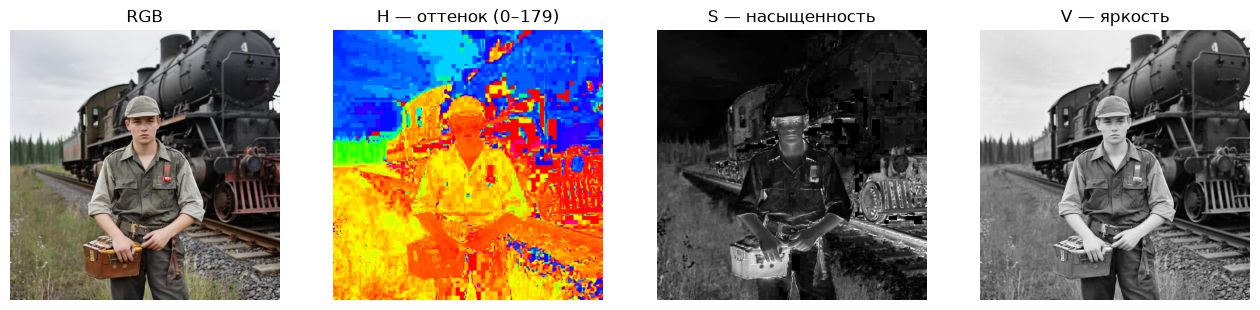

In [1]:
# Работа с цветовыми пространствами

import cv2
import matplotlib.pyplot as plt

img = cv2.imread("../example.jpg")

# RGB — для отображения
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

# HSV — для анализа цвета: H (оттенок), S (насыщенность), V (яркость)
img_hsv = cv2.cvtColor(img, cv2.COLOR_BGR2HSV)

fig, ax = plt.subplots(1, 4, figsize=(16, 4))
ax[0].imshow(img_rgb);                       ax[0].set_title("RGB")
ax[1].imshow(img_hsv[:, :, 0], cmap="hsv"); ax[1].set_title("H — оттенок (0–179)")
ax[2].imshow(img_hsv[:, :, 1], cmap="gray"); ax[2].set_title("S — насыщенность")
ax[3].imshow(img_hsv[:, :, 2], cmap="gray"); ax[3].set_title("V — яркость")
for a in ax:
    a.axis("off")
plt.show()

In [2]:
# Числовые значения канала Hue (оттенок).
#
# ВАЖНО: в теории оттенок измеряется в градусах 0–360°,
# но OpenCV хранит Hue в диапазоне 0–179 (градусы делятся пополам,
# чтобы уместиться в байт uint8). Поэтому, например, «красный» — это
# пороги около 0 и около 179, а не 0–360. Частая ошибка новичков!

print("Диапазон Hue в этом изображении:", img_hsv[:, :, 0].min(), "—", img_hsv[:, :, 0].max())
print()
print("Фрагмент матрицы Hue (пиксели 5×5 из левого верхнего угла):")
print(img_hsv[:5, :5, 0])

Диапазон Hue в этом изображении: 0 — 179

Фрагмент матрицы Hue (пиксели 5×5 из левого верхнего угла):
[[116 116 116 116 116]
 [116 116 116 116 116]
 [116 116 116 116 116]
 [116 116 116 116 116]
 [116 116 116 116 116]]


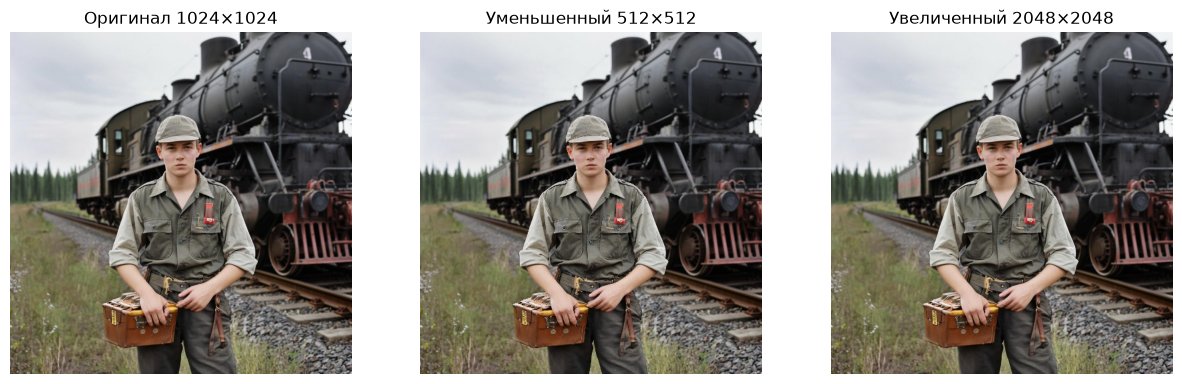

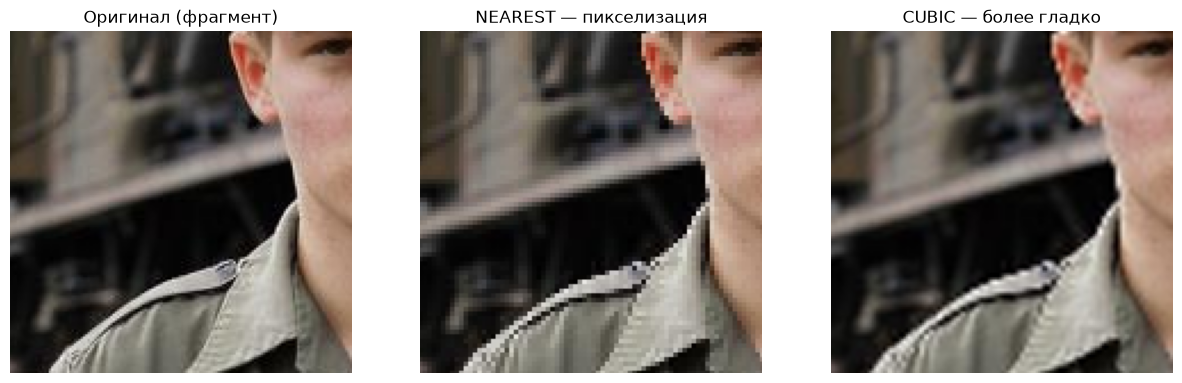

In [3]:
# Масштабирование изображений
#
# ВАЖНО: cv2.resize принимает размер как (ширина, высота),
# а img.shape возвращает (высота, ширина, каналы) — порядок разный!

h, w = img.shape[:2]

# Способ 1: фиксированный размер — (width, height)
resized_small = cv2.resize(img, (w // 2, h // 2), interpolation=cv2.INTER_NEAREST)
resized_big   = cv2.resize(img, (w * 2, h * 2), interpolation=cv2.INTER_CUBIC)

# Способ 2: коэффициенты (в 2 раза меньше / больше — как в индивидуальном задании):
# resized_small = cv2.resize(img, None, fx=0.5, fy=0.5, interpolation=cv2.INTER_NEAREST)
# resized_big   = cv2.resize(img, None, fx=2.0, fy=2.0, interpolation=cv2.INTER_CUBIC)

cv2.imwrite("resized_small.jpg", resized_small)
cv2.imwrite("resized_big.jpg", resized_big)

def to_rgb(im):
    return cv2.cvtColor(im, cv2.COLOR_BGR2RGB)

fig, ax = plt.subplots(1, 3, figsize=(15, 5))
ax[0].imshow(to_rgb(img));           ax[0].set_title(f"Оригинал {w}×{h}")
ax[1].imshow(to_rgb(resized_small)); ax[1].set_title(f"Уменьшенный {w//2}×{h//2}")
ax[2].imshow(to_rgb(resized_big));   ax[2].set_title(f"Увеличенный {w*2}×{h*2}")
for a in ax:
    a.axis("off")
plt.show()

# Сравнение интерполяции: уменьшили → снова увеличили, смотрим один и тот же фрагмент
restored_nearest = cv2.resize(to_rgb(resized_small), (w, h), interpolation=cv2.INTER_NEAREST)
restored_cubic   = cv2.resize(to_rgb(resized_small), (w, h), interpolation=cv2.INTER_CUBIC)

y0, x0, frag = h // 3, w // 3, 150  # одинаковый фрагмент у всех трёх
img_rgb = to_rgb(img)

fig, ax = plt.subplots(1, 3, figsize=(15, 5))
ax[0].imshow(img_rgb[y0:y0+frag, x0:x0+frag]);         ax[0].set_title("Оригинал (фрагмент)")
ax[1].imshow(restored_nearest[y0:y0+frag, x0:x0+frag]); ax[1].set_title("NEAREST — пикселизация")
ax[2].imshow(restored_cubic[y0:y0+frag, x0:x0+frag]);   ax[2].set_title("CUBIC — более гладко")
for a in ax:
    a.axis("off")
plt.show()

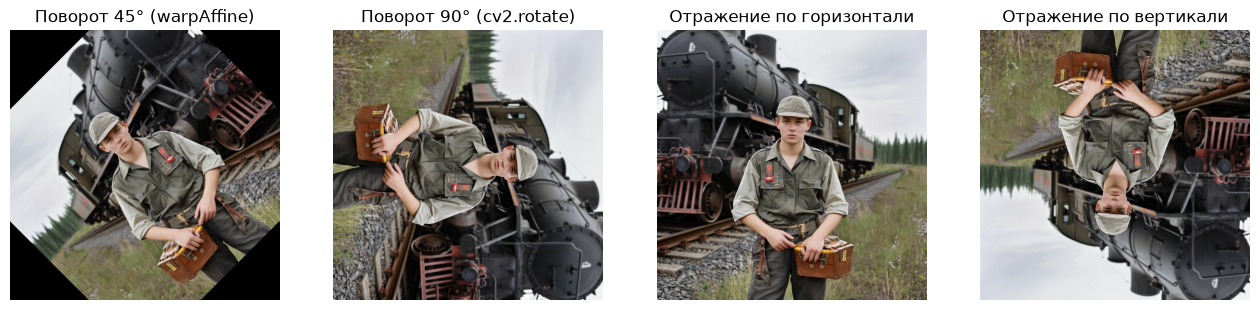

In [4]:
# Поворот и отражение

(h, w) = img.shape[:2]
center = (w // 2, h // 2)

# Поворот на произвольный угол (45°) вокруг центра
M = cv2.getRotationMatrix2D(center, 45, 1.0)
rotated = cv2.warpAffine(img, M, (w, h))

# Для углов, кратных 90°, есть более простой и быстрый способ (без потерь качества):
rotated_90 = cv2.rotate(img, cv2.ROTATE_90_CLOCKWISE)

# Отражения
flipped_h = cv2.flip(img, 1)   # по горизонтали (зеркало)
flipped_v = cv2.flip(img, 0)   # по вертикали (вверх ногами)

def to_rgb(im):
    return cv2.cvtColor(im, cv2.COLOR_BGR2RGB)

fig, ax = plt.subplots(1, 4, figsize=(16, 5))
ax[0].imshow(to_rgb(rotated));    ax[0].set_title("Поворот 45° (warpAffine)")
ax[1].imshow(to_rgb(rotated_90)); ax[1].set_title("Поворот 90° (cv2.rotate)")
ax[2].imshow(to_rgb(flipped_h));  ax[2].set_title("Отражение по горизонтали")
ax[3].imshow(to_rgb(flipped_v));  ax[3].set_title("Отражение по вертикали")
for a in ax:
    a.axis("off")
plt.show()

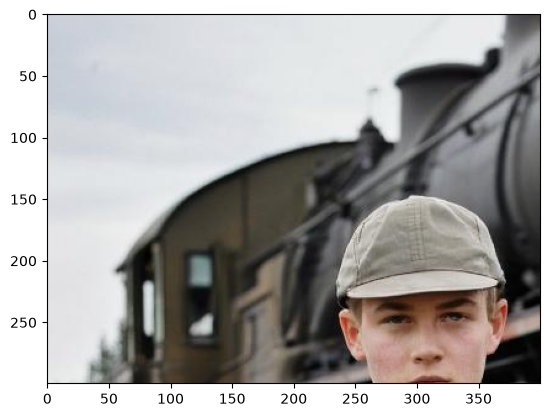

In [5]:
# Обрезка (crop)

cropped = img[100:400, 200:600]  # область по координатам [y1:y2, x1:x2]

plt.imshow(cv2.cvtColor(cropped, cv2.COLOR_BGR2RGB))
plt.show()

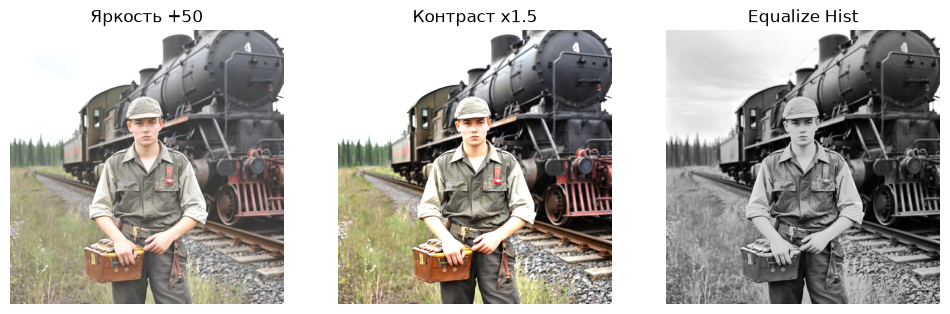

In [6]:
# Работа с яркостью и контрастом

# Увеличение яркости
bright = cv2.convertScaleAbs(img, alpha=1, beta=50)  # beta = смещение яркости

# Увеличение контраста
contrast = cv2.convertScaleAbs(img, alpha=1.5, beta=0)

# Выравнивание гистограммы для grayscale
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
equalized = cv2.equalizeHist(gray)

# Отображение
fig, ax = plt.subplots(1, 3, figsize=(12,4))
ax[0].imshow(cv2.cvtColor(bright, cv2.COLOR_BGR2RGB)); ax[0].set_title("Яркость +50"); ax[0].axis("off")
ax[1].imshow(cv2.cvtColor(contrast, cv2.COLOR_BGR2RGB)); ax[1].set_title("Контраст x1.5"); ax[1].axis("off")
ax[2].imshow(equalized, cmap="gray"); ax[2].set_title("Equalize Hist"); ax[2].axis("off")
plt.show()


До:    dtype = uint8 , min–max: 0 – 255
После: dtype = float64 , min–max: 0.0 – 1.0


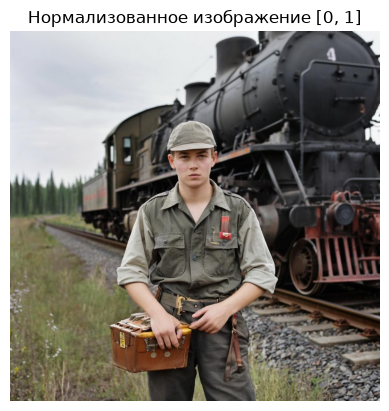

In [7]:
# Нормализация: перевод значений пикселей в диапазон [0, 1]
# Именно в таком виде изображения подают на вход нейросетям (занятия 6–7)

img_norm = img_rgb / 255.0   # uint8 [0..255] → float [0..1]

print("До:    dtype =", img_rgb.dtype, ", min–max:", img_rgb.min(), "–", img_rgb.max())
print("После: dtype =", img_norm.dtype, ", min–max:", round(float(img_norm.min()), 3), "–", round(float(img_norm.max()), 3))

plt.imshow(img_norm)  # выглядит так же — изменились только числа внутри массива
plt.title("Нормализованное изображение [0, 1]")
plt.axis("off")
plt.show()

Индивидуальные задания студентам

Прочитать изображение и отобразить его в RGB, HSV и Grayscale.

Масштабировать изображение в 2 раза меньше и в 2 раза больше, сравнить качество.

Написать функцию, которая поворачивает изображение на 90°.

Вырезать из изображения центральный фрагмент размером 200×200 пикселей.

Увеличить яркость и контраст изображения и сохранить результат.

(Дополнительно) Реализовать свою функцию нормализации:

Привести значения пикселей к диапазону [0,1].

Умножить на коэффициент и обратно привести к [0,255].

In [8]:
# Индивидуальное задание

# Загрузка своего изображения
img = cv2.imread('my_ex.jpeg')
print('Размер:', img.shape)

Размер: (562, 749, 3)


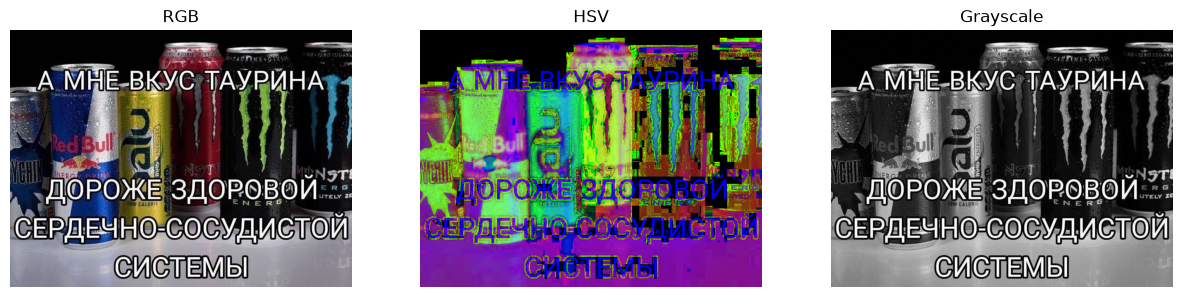

In [9]:
# RGB, HSV и Grayscale
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
img_hsv = cv2.cvtColor(img, cv2.COLOR_BGR2HSV)
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

fig, ax = plt.subplots(1, 3, figsize=(15, 5))
ax[0].imshow(img_rgb)
ax[0].set_title('RGB')
ax[1].imshow(img_hsv)
ax[1].set_title('HSV')
ax[2].imshow(gray, cmap='gray')
ax[2].set_title('Grayscale')

for a in ax:
    a.axis('off')
plt.show()

Оригинал: (562, 749, 3)
В 2 раза меньше: (281, 374, 3)
В 2 раза больше: (1124, 1498, 3)


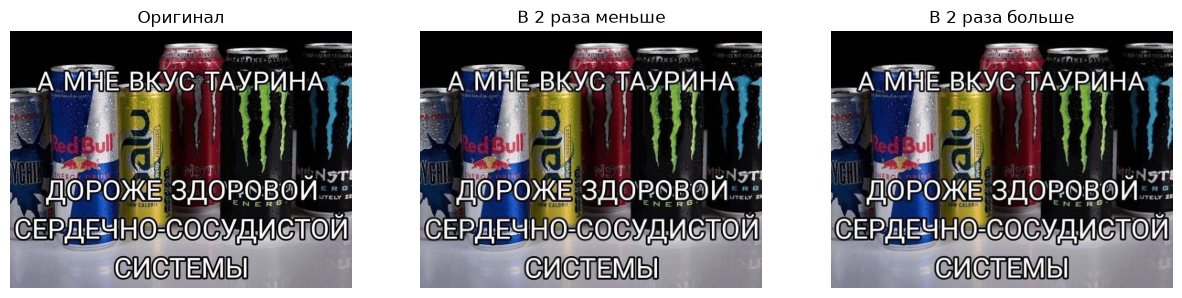

In [14]:
# Уменьшение и увеличение изображения
small = cv2.resize(img, None, fx=0.5, fy=0.5)
big = cv2.resize(img, None, fx=2, fy=2)

print('Оригинал:', img.shape)
print('В 2 раза меньше:', small.shape)
print('В 2 раза больше:', big.shape)

fig, ax = plt.subplots(1, 3, figsize=(15, 5))
ax[0].imshow(img_rgb)
ax[0].set_title('Оригинал')
ax[1].imshow(cv2.cvtColor(small, cv2.COLOR_BGR2RGB))
ax[1].set_title('В 2 раза меньше')
ax[2].imshow(cv2.cvtColor(big, cv2.COLOR_BGR2RGB))
ax[2].set_title('В 2 раза больше')

for a in ax:
    a.axis('off')
plt.show()

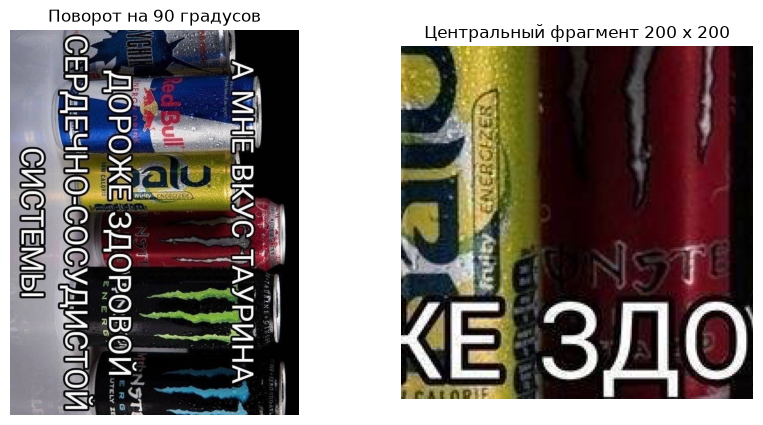

In [11]:
# Поворот на 90 градусов
def rotate_90(image):
    return cv2.rotate(image, cv2.ROTATE_90_CLOCKWISE)

rotated = rotate_90(img)

# Центральный фрагмент 200 x 200
h, w = img.shape[:2]
cropped = img[h // 2 - 100:h // 2 + 100, w // 2 - 100:w // 2 + 100]

fig, ax = plt.subplots(1, 2, figsize=(10, 5))
ax[0].imshow(cv2.cvtColor(rotated, cv2.COLOR_BGR2RGB))
ax[0].set_title('Поворот на 90 градусов')
ax[1].imshow(cv2.cvtColor(cropped, cv2.COLOR_BGR2RGB))
ax[1].set_title('Центральный фрагмент 200 x 200')

for a in ax:
    a.axis('off')
plt.show()

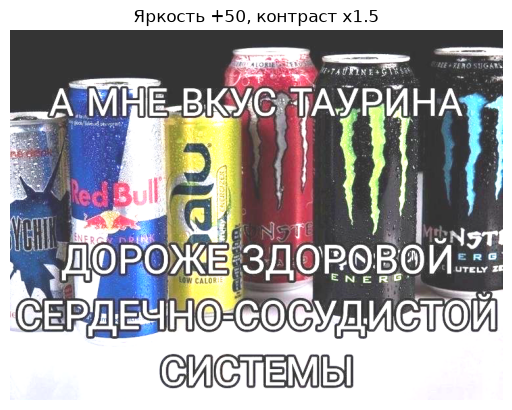

In [12]:
# Увеличение яркости и контраста
result = cv2.convertScaleAbs(img, alpha=1.5, beta=50)
cv2.imwrite('bright_contrast.jpg', result)

plt.imshow(cv2.cvtColor(result, cv2.COLOR_BGR2RGB))
plt.title('Яркость +50, контраст x1.5')
plt.axis('off')
plt.show()

In [13]:
# Дополнительно: нормализация
img_norm = img_rgb / 255.0
img_back = (img_norm * 255).astype('uint8')

print('Нормализованные значения:', img_norm.min(), '—', img_norm.max())
print('После возврата:', img_back.min(), '—', img_back.max())

Нормализованные значения: 0.0 — 1.0
После возврата: 0 — 255
